# Summer mean temp for Land (not Coastal) vs Ocean vs Coastal - look into whether the results are different for different latitude zones to see if the initial result for the NH midlatitudes having a lower SummerMeanT for coastal than either ocean or land is explainable

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from mpl_toolkits.basemap import Basemap

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [10]:
# read in data for land and ocean
# input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_LAND_summer_stats.nc'
# ds_land = xr.open_dataset(input_path)

# input_path2 = '../../../Data/ERA5-global/Analysis/New/1961-2023_OCEAN_summer_stats.nc'
# ds_ocean = xr.open_dataset(input_path2)
# merge land and ocean for now
#ds_full = ds_land.merge(ds_ocean)

# read in ALL data for ocean, land, and coastal areas with all flags
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)

# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

ds_full


<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

<unknown>:85: SyntaxWarning: invalid escape sequence '\p'
<unknown>:88: SyntaxWarning: invalid escape sequence '\p'
<unknown>:91: SyntaxWarning: invalid escape sequence '\p'
<unknown>:145: SyntaxWarning: invalid escape sequence '\p'
<unknown>:148: SyntaxWarning: invalid escape sequence '\p'
<unknown>:151: SyntaxWarning: invalid escape sequence '\p'


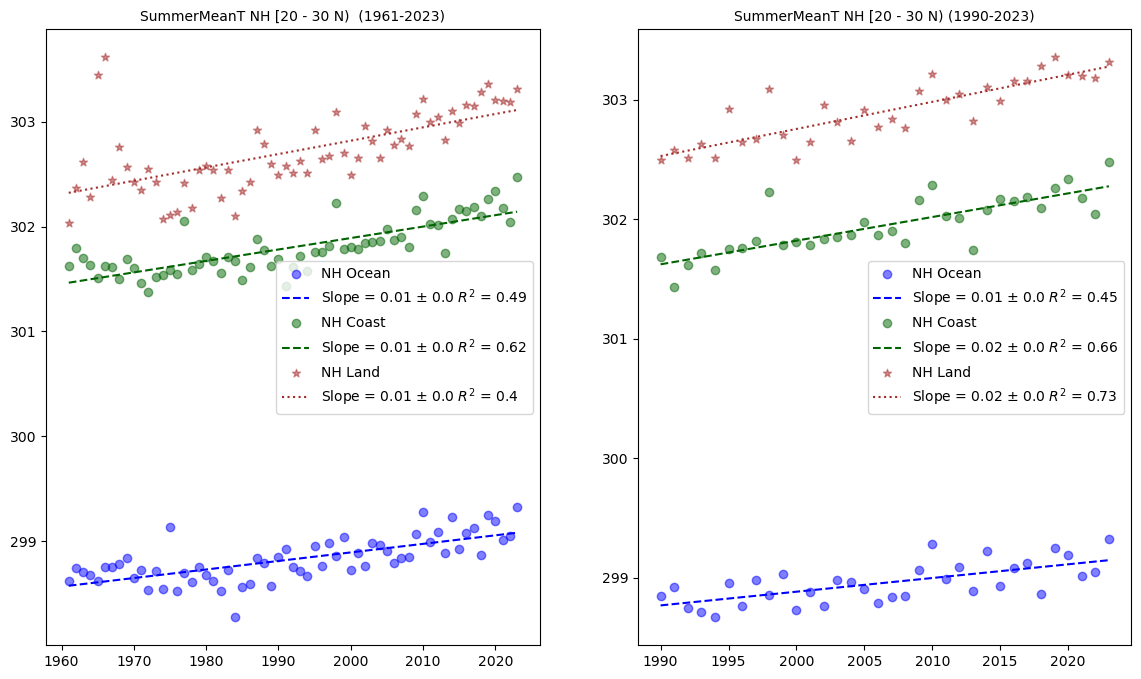

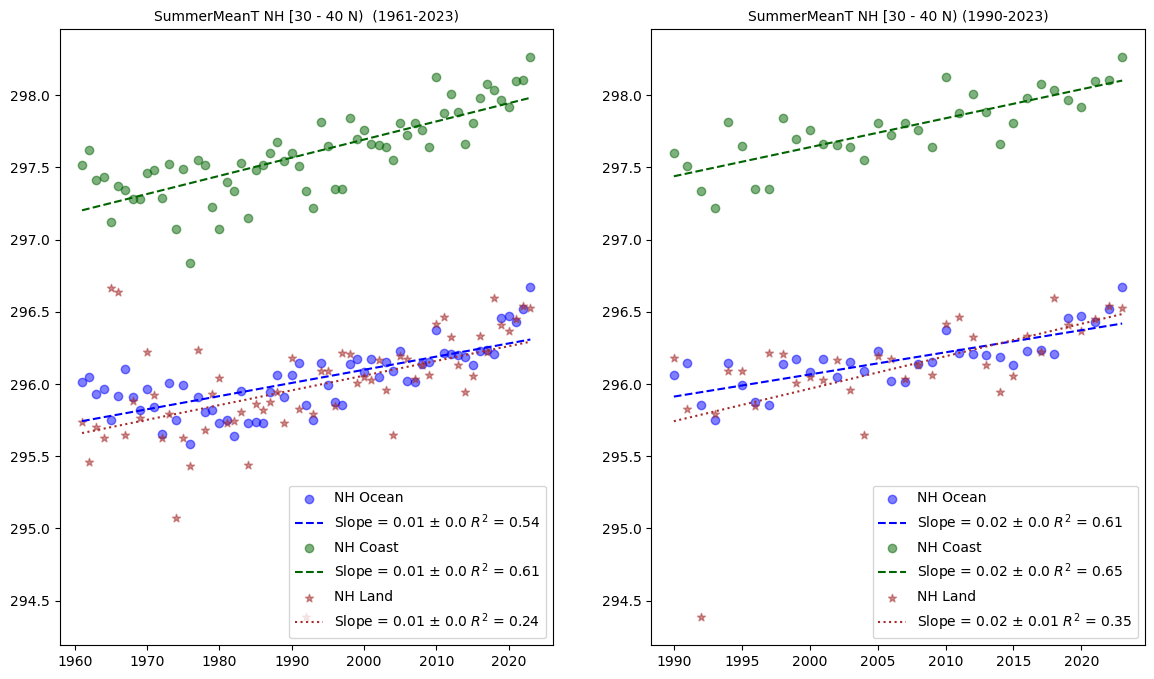

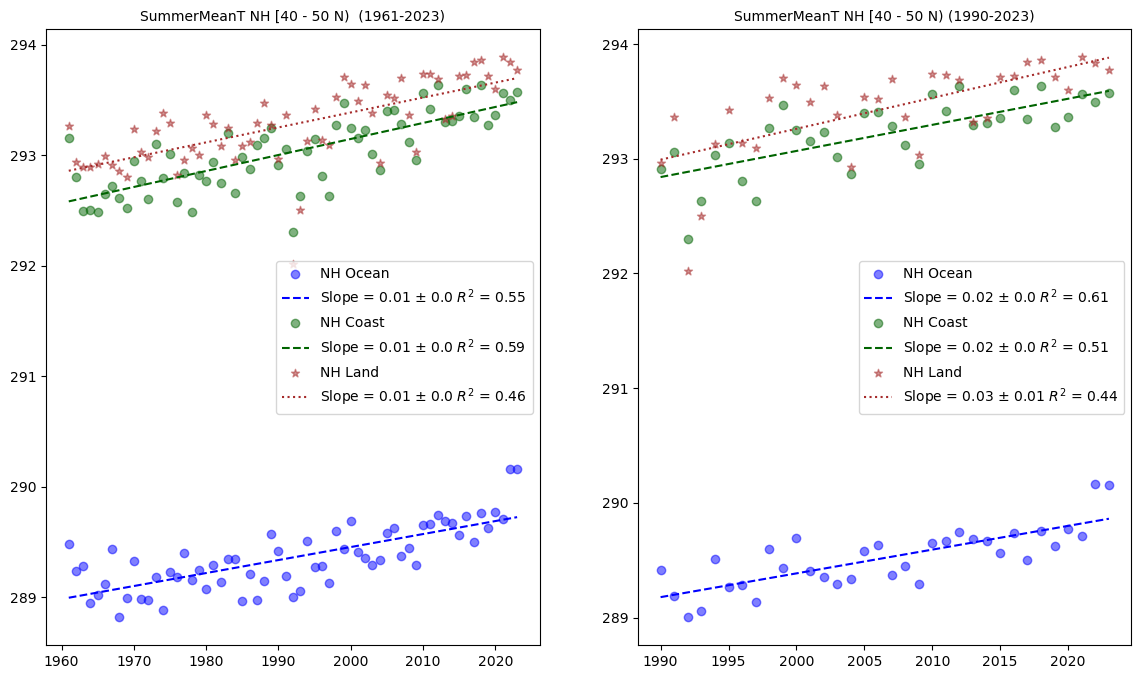

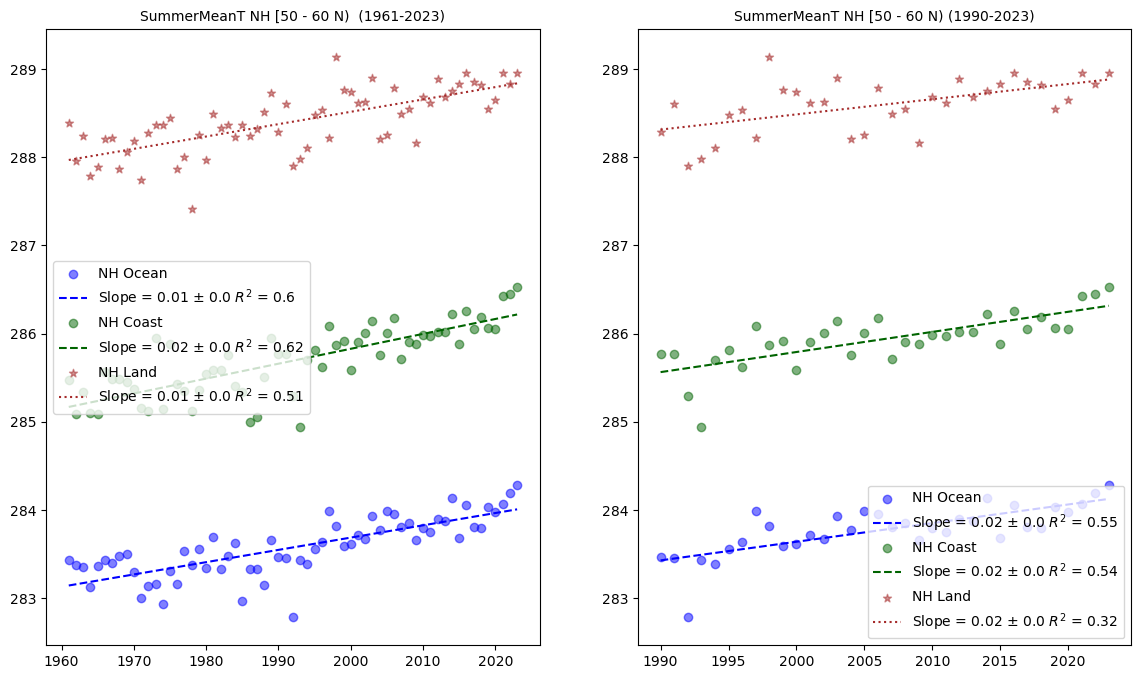

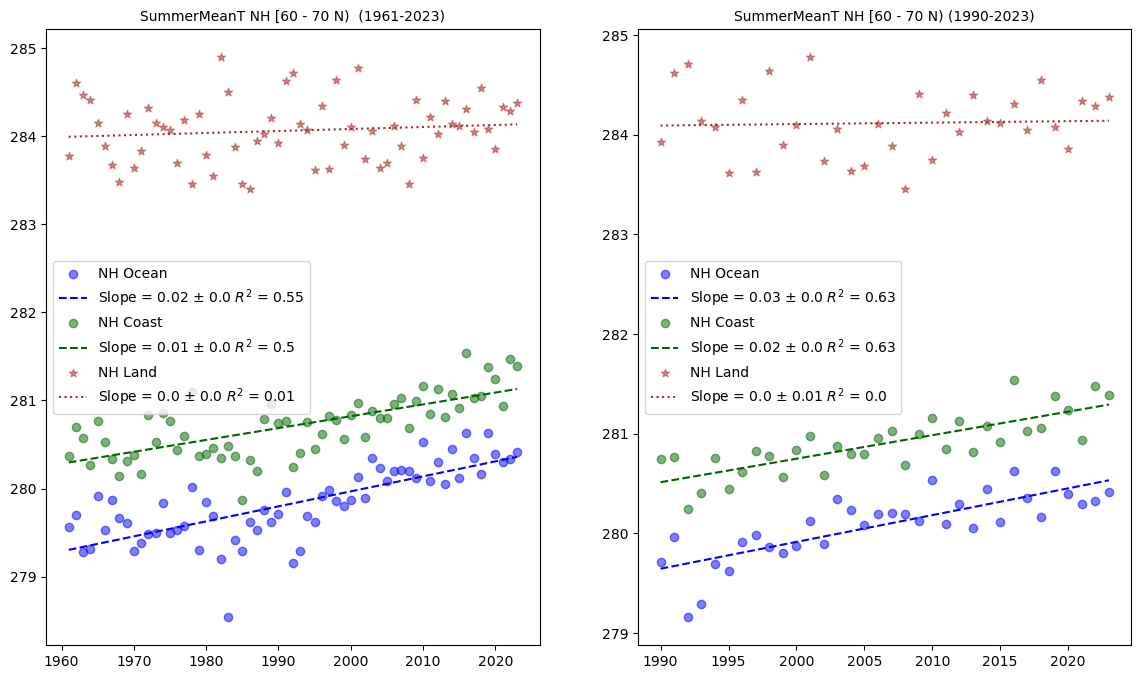

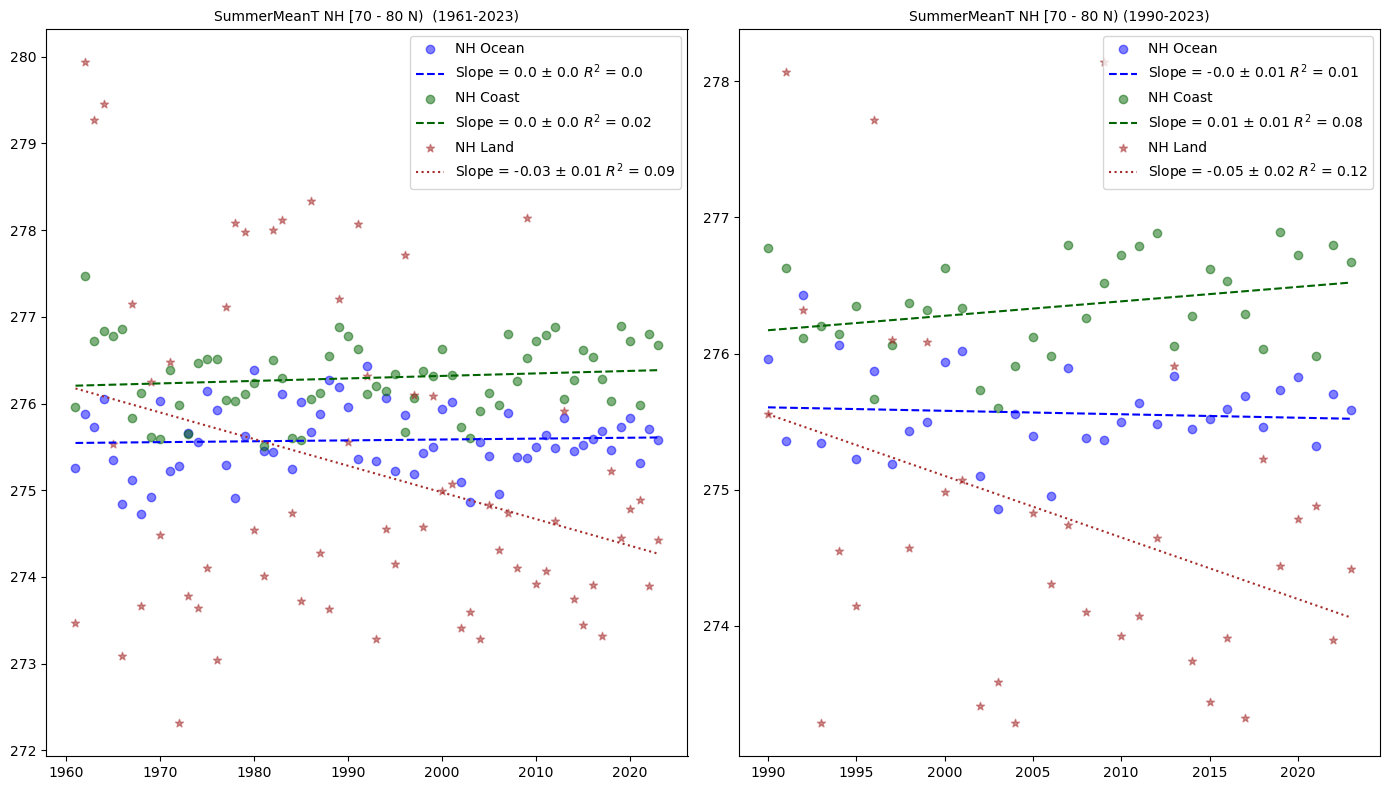

CPU times: user 1min 14s, sys: 45.5 s, total: 1min 59s
Wall time: 2min 26s


In [12]:
%%time

# takes 2.5 min


# 10 degree latitude buckets
lat_bins = [20,30,40,50,60,70]



# loop through all plot variables
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
    nh_land_full = ds_full.where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    nh_coast_full = ds_full.where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_ocean_full = ds_full.where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_ocean_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    nh_land_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_coast_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    
    # create blank fig
    fig = plt.figure(figsize = (14,8))
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = nh_coast_full.time.dt.year.values
    y_coast = nh_coast_full.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", alpha=0.5)
    ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax1.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax1.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("SummerMeanT NH [" + str(v) +" - " + str(v+10) + " N)  (1961-2023)", fontsize = 10)
    ax1.legend(loc='best')



    # Analysis time period NH
    ax2 = fig.add_subplot(1,2,2)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = nh_coast_an.time.dt.year.values
    y_coast = nh_coast_an.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax2.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", alpha=0.5)
    ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax2.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax2.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("SummerMeanT NH [" + str(v) +" - " + str(v+10) + " N) (1990-2023)", fontsize = 10)
    ax2.legend(loc='best')


plt.tight_layout()
plt.show()

## What are the average latitudes for Inland, Coastal, and Ocean in the NH?

In [42]:
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes
# for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
# quick counts suggest this loses 1.5 - 2% of grid cells across the 63 years
nh_land_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

nh_coast_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

nh_ocean_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) & 
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

print("Mean lat for Inland: "+str(nh_land_mean_lat))
print("Mean lat for Coastal: "+str(nh_coast_mean_lat))
print("Mean lat for Ocean: "+str(nh_ocean_mean_lat))

Mean lat for Inland: <xarray.DataArray 'lat' ()> Size: 8B
array(49.45327469)
Mean lat for Coastal: <xarray.DataArray 'lat' ()> Size: 8B
array(50.96078641)
Mean lat for Ocean: <xarray.DataArray 'lat' ()> Size: 8B
array(43.73284943)


## Boxplots

In [65]:
# pick a year
nh_land_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)

nh_coast_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.Coastal == True) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)

nh_ocean_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) & 
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)



In [68]:
np.count_nonzero(~np.isnan(nh_coast_lat)), np.count_nonzero(~np.isnan(nh_land_lat)), np.count_nonzero(~np.isnan(nh_ocean_lat))

(7032, 137784, 127401)

### Seems I have to loop through each to build the list of latitude values

In [78]:
%%time

# build list of lat values for each subset
# each needs its own loop since not all lon values are represented in each dataset
land_lats=[]
for i in nh_land_lat.lat.values:
    for j in nh_land_lat.lon.values:
        if(~np.isnan(nh_land_lat.sel(lat=i, lon=j))):
            land_lats.append(i)

coast_lats=[]
for i in nh_coast_lat.lat.values:
    for j in nh_coast_lat.lon.values:
        if(~np.isnan(nh_coast_lat.sel(lat=i, lon=j))):
            coast_lats.append(i)

ocean_lats=[]
for i in nh_ocean_lat.lat.values:
    for j in nh_ocean_lat.lon.values:
        if(~np.isnan(nh_ocean_lat.sel(lat=i, lon=j))):
            ocean_lats.append(i)



CPU times: user 1min 23s, sys: 26.9 ms, total: 1min 23s
Wall time: 1min 23s


Text(0.5, 1.0, 'Distribution of latitudes of grid cells for each classification - NH Midlatitudes [23.5 - 70 N]')

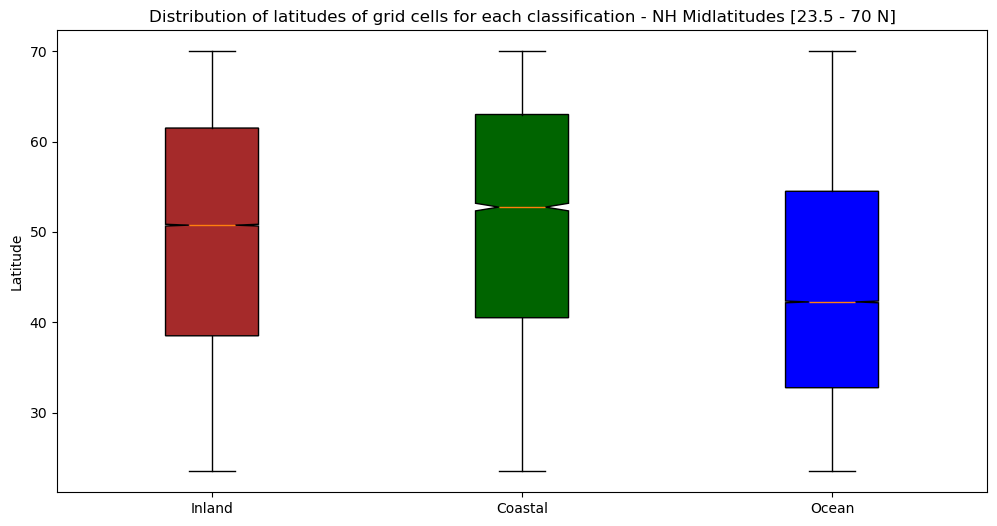

In [84]:
# help from https://www.geeksforgeeks.org/box-plot-in-python-using-matplotlib/#

data = [land_lats, coast_lats, ocean_lats]

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

# Creating axes instance
bp = ax.boxplot(data, patch_artist = True,
                notch ='True',)

colors = ['brown', 'darkgreen', 'blue']
labels = ['Inland', 'Coastal', 'Ocean']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# x-axis labels
ax.set_xticklabels(labels)

ax.set_ylabel("Latitude")

# Adding title 
plt.title("Distribution of latitudes of grid cells for each classification - NH Midlatitudes [23.5 - 70 N]")

### Violin plots instead

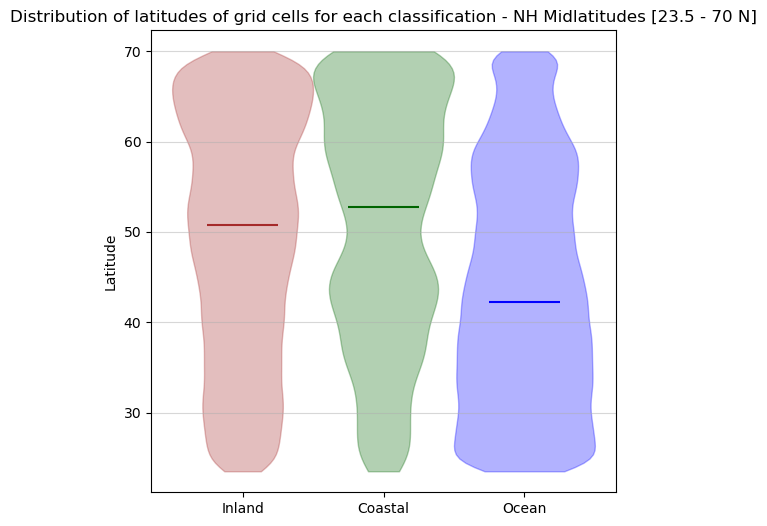

In [89]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
plots = ax.violinplot(data, vert=True, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_ylabel("Latitude")
ax.set_xticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="y", which='both', alpha=0.5)
plt.title("Distribution of latitudes of grid cells for each classification - NH Midlatitudes [23.5 - 70 N]")
plt.show()